In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ---------------------------------------------------------
# 1. PARAMETRELER VE KLASÖR YOLLARI
# ---------------------------------------------------------
base_dir = 'archive (4)'

# Siyah-beyaz (girdi) ve renkli (hedef) görüntülerin dosya yolları tanımlanıyor
train_color_dir = os.path.join(base_dir, 'train', 'color')
train_gray_dir = os.path.join(base_dir, 'train', 'gray')
val_color_dir = os.path.join(base_dir, 'val', 'color')
val_gray_dir = os.path.join(base_dir, 'val', 'gray')

batch_size = 32    # RAM kullanımını dengelemek ve I/O darboğazını aşmak için optimum yığın boyutu
img_size = 128     # Hesaplama maliyeti ile görüntü kalitesi arasında optimizasyon sağlamak için 128x128 seçilmiştir

print("1. Veri yolları alınıyor ve klasör bazlı eşleştiriliyor...")

# Siyah-beyaz ve renkli görsellerin dosya isimlerinin birebir eşleşmesini sağlayan yardımcı fonksiyon
def get_matched_paths(color_dir, gray_dir):
    image_names = sorted(os.listdir(color_dir))
    # Sadece resim formatlarını filtrele
    image_names = [f for f in image_names if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    color_paths = []
    gray_paths = []
    
    for img_name in image_names:
        color_paths.append(os.path.join(color_dir, img_name))
        gray_paths.append(os.path.join(gray_dir, img_name))
        
    return gray_paths, color_paths

# Eğitim ve Doğrulama setleri için dosya yollarını ayrı ayrı topluyoruz
train_gray_paths, train_color_paths = get_matched_paths(train_color_dir, train_gray_dir)
val_gray_paths, val_color_paths = get_matched_paths(val_color_dir, val_gray_dir)

# ---------------------------------------------------------
# 2. TENSORFLOW DATASET OLUŞTURMA VE ÖN İŞLEME
# ---------------------------------------------------------
# Verileri diske sığmadığı için RAM'e tek seferde yüklemek yerine Pipeline (Boru Hattı) ile akıtıyoruz.
def process_path(gray_path, color_path):
    # Siyah-Beyaz Görüntüyü Oku ve İşle (Girdi)
    gray_img = tf.io.read_file(gray_path)
    gray_img = tf.image.decode_jpeg(gray_img, channels=1) # 1 Kanal (Sadece luma/parlaklık değeri)
    gray_img = tf.image.resize(gray_img, [img_size, img_size])
    gray_img = gray_img / 255.0  # Pikselleri [0, 1] aralığına normalize et (Modelin daha hızlı öğrenmesini sağlar)
    
    # Renkli Görüntüyü Oku ve İşle (Hedef Çıktı)
    color_img = tf.io.read_file(color_path)
    color_img = tf.image.decode_jpeg(color_img, channels=3) # 3 Kanal (RGB)
    color_img = tf.image.resize(color_img, [img_size, img_size])
    color_img = color_img / 255.0
    
    return gray_img, color_img

# Eğitim Seti Pipeline'ı
train_ds = tf.data.Dataset.from_tensor_slices((train_gray_paths, train_color_paths))
train_ds = train_ds.shuffle(buffer_size=len(train_gray_paths), seed=42)

# Doğrulama Seti Pipeline'ı
val_ds = tf.data.Dataset.from_tensor_slices((val_gray_paths, val_color_paths))

# Performans Optimizasyonları ve Batch Ayarları (RAM dostu hale getirildi)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(process_path, num_parallel_calls=AUTOTUNE).batch(batch_size).prefetch(AUTOTUNE)
val_ds = val_ds.map(process_path, num_parallel_calls=AUTOTUNE).batch(batch_size).prefetch(AUTOTUNE)

print(f"Eğitim Seti Görsel Sayısı: {len(train_gray_paths)}")
print(f"Doğrulama Seti Görsel Sayısı: {len(val_gray_paths)}")

# ---------------------------------------------------------
# 3. MICRO U-NET MODEL KURULUMU
# ---------------------------------------------------------
print("\n2. Mikro U-Net Kuruluyor...")
def build_micro_unet(input_shape=(img_size, img_size, 1)):
    inputs = layers.Input(shape=input_shape)
    
    # ENCODER (Kodlayıcı): Görüntünün boyutunu küçültüp, özellik haritalarını (feature maps) derinleştirir.
    c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D((2, 2))(c2)
    
    # BOTTLE-NECK (Darboğaz): Verinin en sıkıştırılmış (latent space) halidir.
    bn = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    
    # DECODER (Çözücü): Sıkıştırılmış veriyi tekrar orijinal boyutuna (128x128) yükseltir.
    # U-NET MİMARİSİNİN ÖZÜ (SKIP CONNECTIONS): Concatenate ile Encoder'daki yüksek çözünürlüklü detaylar
    # doğrudan Decoder'a aktarılır. Bu sayede kenar ve sınır çizgilerindeki bulanıklaşma önlenir.
    u1 = layers.UpSampling2D((2, 2))(bn)
    concat1 = layers.concatenate([u1, c2]) 
    c3 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(concat1)
    
    u2 = layers.UpSampling2D((2, 2))(c3)
    concat2 = layers.concatenate([u2, c1]) 
    c4 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(concat2)

    # ÇIKTI KATMANI: RGB (3 kanal) renkli görüntüyü oluşturur. 
    # Sigmoid fonksiyonu piksel değerlerinin tam [0, 1] aralığına oturmasını garanti eder.
    outputs = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(c4)
    return models.Model(inputs, outputs)

1. Veri yolları alınıyor ve klasör bazlı eşleştiriliyor...
Eğitim Seti Görsel Sayısı: 118287
Doğrulama Seti Görsel Sayısı: 5000

2. Mikro U-Net Kuruluyor...


In [2]:
model = build_micro_unet()
model.compile(optimizer='adam', loss='mse', metrics=['accuracy']) 
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)
# ---------------------------------------------------------
# 4. MODEL EĞİTİMİ
# ---------------------------------------------------------
print("\n3. Model Eğitimi Başlıyor (GPU Devredeyse Çok Hızlı Sürecek)...")
history = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=[early_stop])


3. Model Eğitimi Başlıyor (GPU Devredeyse Çok Hızlı Sürecek)...
Epoch 1/10
3697/3697 [==============================] - 144s 38ms/step - loss: 0.0077 - accuracy: 0.4909 - val_loss: 0.0071 - val_accuracy: 0.4927
Epoch 2/10
3697/3697 [==============================] - 145s 39ms/step - loss: 0.0068 - accuracy: 0.5086 - val_loss: 0.0065 - val_accuracy: 0.5080
Epoch 3/10
3697/3697 [==============================] - 146s 39ms/step - loss: 0.0066 - accuracy: 0.5165 - val_loss: 0.0066 - val_accuracy: 0.5003
Epoch 4/10
3697/3697 [==============================] - 144s 39ms/step - loss: 0.0065 - accuracy: 0.5213 - val_loss: 0.0064 - val_accuracy: 0.5009
Epoch 5/10
3697/3697 [==============================] - 143s 39ms/step - loss: 0.0064 - accuracy: 0.5250 - val_loss: 0.0063 - val_accuracy: 0.5312
Epoch 6/10
3697/3697 [==============================] - 144s 39ms/step - loss: 0.0064 - accuracy: 0.5270 - val_loss: 0.0063 - val_accuracy: 0.5038
Epoch 7/10
3697/3697 [==============================]

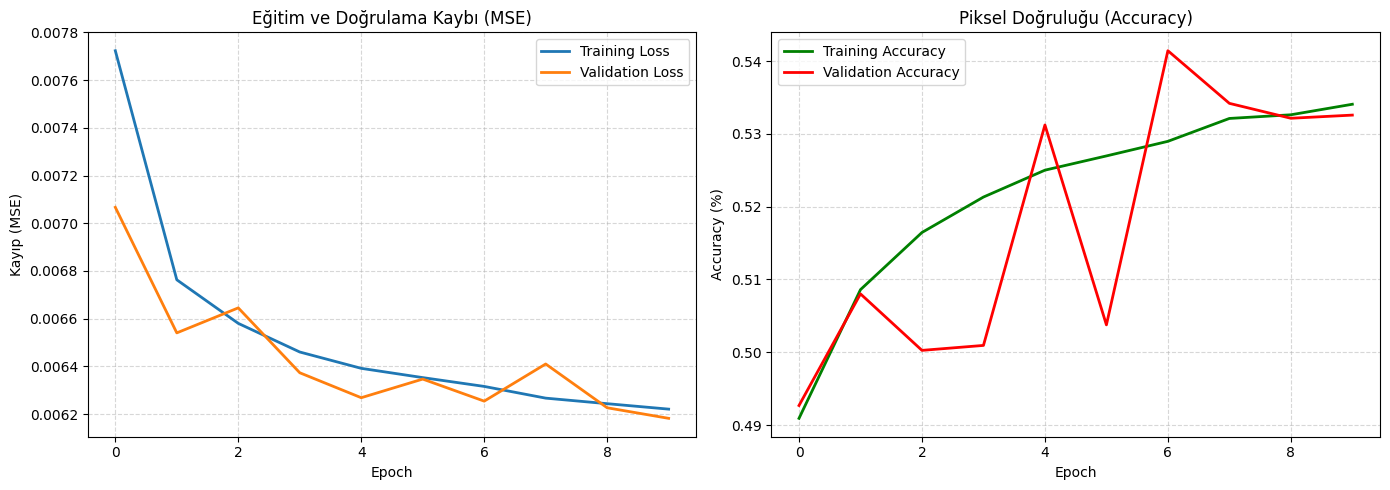

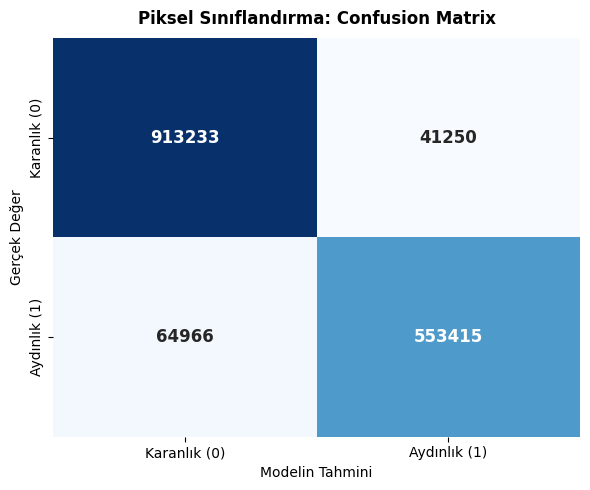


--- SINIFLANDIRMA RAPORU (Precision, Recall, F1-Score) ---
                    precision    recall  f1-score   support

Karanlık Pikseller       0.93      0.96      0.95    954483
Aydınlık Pikseller       0.93      0.89      0.91    618381

          accuracy                           0.93   1572864
         macro avg       0.93      0.93      0.93   1572864
      weighted avg       0.93      0.93      0.93   1572864



In [3]:
# ---------------------------------------------------------
# 5. LOSS VE ACCURACY GRAFİKLERİ
# ---------------------------------------------------------
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(len(loss))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
plt.title('Eğitim ve Doğrulama Kaybı (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Kayıp (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2, color='green')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, color='red')
plt.title('Piksel Doğruluğu (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6. CONFUSION MATRIX VE F1-SCORE
# ---------------------------------------------------------
val_batch = next(iter(val_ds))
x_val_gray = val_batch[0]
y_val_real = val_batch[1]
y_pred_color = model.predict(x_val_gray, verbose=0)

y_true_flat = (y_val_real.numpy().flatten() > 0.5).astype(int)
y_pred_flat = (y_pred_color.flatten() > 0.5).astype(int)

cm = confusion_matrix(y_true_flat, y_pred_flat)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Karanlık (0)', 'Aydınlık (1)'], 
            yticklabels=['Karanlık (0)', 'Aydınlık (1)'],
            annot_kws={"size": 12, "weight": "bold"}, cbar=False)
plt.title('Piksel Sınıflandırma: Confusion Matrix', fontweight='bold', pad=10)
plt.xlabel('Modelin Tahmini')
plt.ylabel('Gerçek Değer')
plt.tight_layout()
plt.show()

print("\n--- SINIFLANDIRMA RAPORU (Precision, Recall, F1-Score) ---")
print(classification_report(y_true_flat, y_pred_flat, target_names=['Karanlık Pikseller', 'Aydınlık Pikseller']))

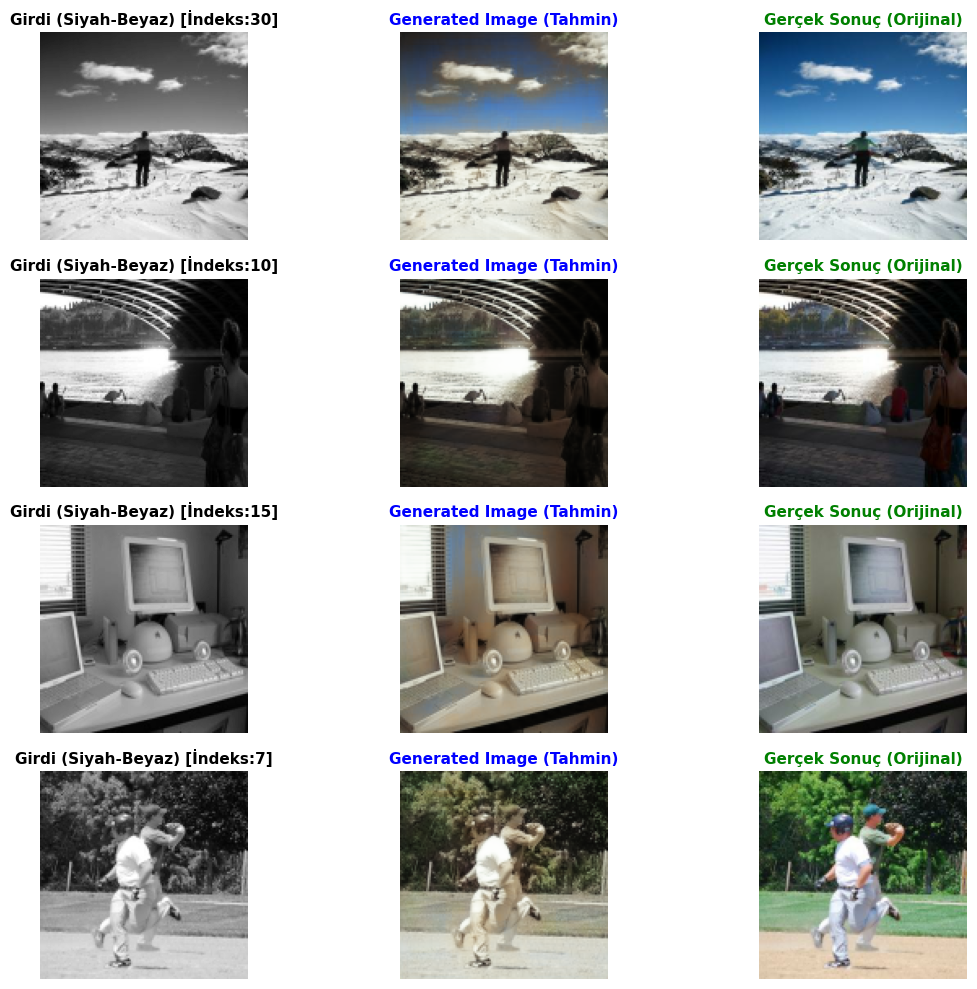

In [123]:
# ---------------------------------------------------------
# 7. GENERATED IMAGE / RECONSTRUCTION KARŞILAŞTIRMASI
# ---------------------------------------------------------
n = 4 
plt.figure(figsize=(12, 10))

total_images_in_batch = x_val_gray.shape[0]
n_samples = min(n, total_images_in_batch)

np.random.seed(None) 
random_indices = np.random.choice(total_images_in_batch, n_samples, replace=False)

for i, idx in enumerate(random_indices):
    # 1. Girdi (Siyah-Beyaz)
    ax = plt.subplot(n_samples, 3, i*3 + 1)
    plt.imshow(tf.squeeze(x_val_gray[idx]), cmap='gray')
    plt.title(f"Girdi (Siyah-Beyaz) [İndeks:{idx}]", fontsize=11, fontweight='bold')
    plt.axis('off')

    # 2. Model Çıktısı (Tahmin Edilen Renkli)
    ax = plt.subplot(n_samples, 3, i*3 + 2)
    plt.imshow(y_pred_color[idx])
    plt.title("Generated Image (Tahmin)", fontsize=11, fontweight='bold', color='blue')
    plt.axis('off')

    # 3. Gerçek Karşılaştırma (Orijinal Renkli)
    ax = plt.subplot(n_samples, 3, i*3 + 3)
    plt.imshow(y_val_real[idx])
    plt.title("Gerçek Sonuç (Orijinal)", fontsize=11, fontweight='bold', color='green')
    plt.axis('off')

plt.tight_layout()
plt.show()

https://www.kaggle.com/datasets/seungjunleeofficial/image-colorization